In [1]:
!pip install -q roboflow tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 33.8 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("2026-oss").project("ai-picture-book-page-detection")
dataset = project.version(2).download("folder")

loading Roboflow workspace...
loading Roboflow project...
Exporting format folder in progress : 23.0%
Version export complete for folder format



Extracting Dataset Version Zip to AI-Picture-Book-Page-Detection-2 in folder:: 100%|██████████| 1199/1199 [00:00<00:00, 1935.67it/s]


In [3]:
import os

print(dataset.location)
print(os.listdir(dataset.location))

/content/AI-Picture-Book-Page-Detection-2
['README.roboflow.txt', 'valid', 'README.dataset.txt', 'test', 'train']


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

DATA_DIR = dataset.location

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "valid"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 추가
test_file_paths = test_ds.file_paths

class_names = train_ds.class_names
print(class_names)

Found 1047 files belonging to 4 classes.
Found 100 files belonging to 4 classes.
Found 50 files belonging to 4 classes.
['none', 'page1', 'page2', 'page3']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 598ms/step - accuracy: 0.4537 - loss: 1.2643 - val_accuracy: 0.8000 - val_loss: 0.7513
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 585ms/step - accuracy: 0.7564 - loss: 0.6850 - val_accuracy: 0.9900 - val_loss: 0.3983
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 626ms/step - accuracy: 0.8930 - loss: 0.4237 - val_accuracy: 0.9900 - val_loss: 0.2409
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 572ms/step - accuracy: 0.9341 - loss: 0.3024 - val_accuracy: 0.9900 - val_loss: 0.1555
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 613ms/step - accuracy: 0.9666 - loss: 0.2133 - val_accuracy: 0.9900 - val_loss: 0.1107
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 578ms/step - accuracy: 0.9847 - loss: 0.1638 - val_accuracy: 0.9900 - val_loss: 0.0832
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 602ms/step - accuracy: 0.9828 - loss: 0.1284 - val_accuracy: 0.9900 - val_loss: 0.0670
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 598ms/step - accuracy: 0.9876 - loss: 0.1077 - val_accu

In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 1.0000 - loss: 0.0150
Test Accuracy: 1.0


In [10]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

# 저장 경로
SAVE_DIR = "/content/page_classifier_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# 0. test 파일 경로 다시 가져오기

file_paths = test_file_paths


# 1. class_names 저장
with open(os.path.join(SAVE_DIR, "page_classifier_class_names.json"), "w") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

# 2. history 저장
history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(SAVE_DIR, "page_classifier_history.csv"), index=False)

# 3. test 예측
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(np.max(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# 4. classification report 저장
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

with open(os.path.join(SAVE_DIR, "page_classifier_report.json"), "w") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(classification_report(y_true, y_pred, target_names=class_names))

# 5. confusion matrix 저장
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{name}" for name in class_names],
    columns=[f"pred_{name}" for name in class_names]
)

cm_df.to_csv(os.path.join(SAVE_DIR, "page_classifier_confusion_matrix.csv"))

print(cm_df)

# 6. 이미지별 예측 결과 저장
result_df = pd.DataFrame({
    "file_path": file_paths,
    "true_label": [class_names[i] for i in y_true],
    "pred_label": [class_names[i] for i in y_pred],
    "confidence": y_prob,
    "correct": y_true == y_pred
})

result_df.to_csv(os.path.join(SAVE_DIR, "page_classifier_predictions.csv"), index=False)

# 7. 최종 모델 저장
model.save(os.path.join(SAVE_DIR, "page_classifier_mobilenetv2.keras"))

print("저장 완료:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

        none       1.00      1.00      1.00        13
       page1       1.00      1.00      1.00        11
       page2       1.00      1.00      1.00        16
       page3       1.00      1.00      1.00        10

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

            pred_none  pred_page1  pred_page2  pred_page3
true_none          13           0           0           0
true_page1          0          11           0           0
true_page2          0           0          16           0
true_page3          0           0           0          10
저장 완료: /content/page_classifier_results
['page_classifier_confusion_matrix.csv', 'page_classifier_mobilenetv2.keras', 'page_c

In [11]:
model.save("/content/page_classifier_mobilenetv2.keras")

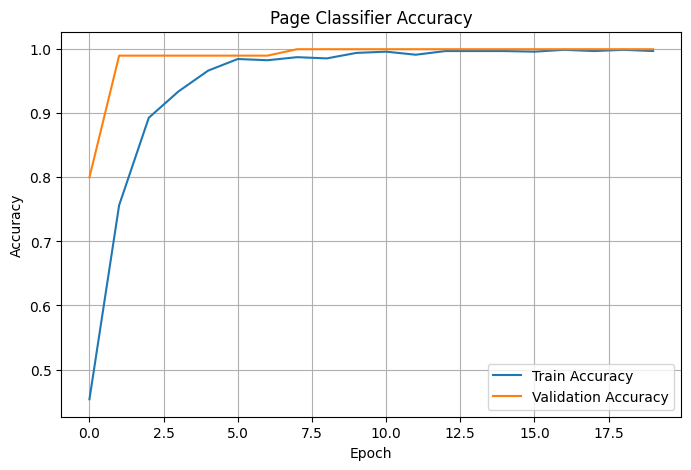

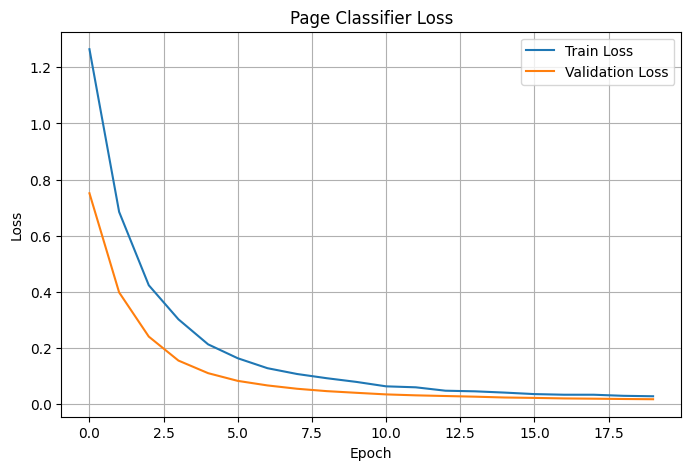

그래프 저장 완료:
/content/page_classifier_results/page_classifier_accuracy.png
/content/page_classifier_results/page_classifier_loss.png


In [12]:
import matplotlib.pyplot as plt
import os

# 학습 정확도 / 손실 그래프 저장
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Page Classifier Accuracy")
plt.legend()
plt.grid(True)

acc_path = os.path.join(SAVE_DIR, "page_classifier_accuracy.png")
plt.savefig(acc_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Page Classifier Loss")
plt.legend()
plt.grid(True)

loss_path = os.path.join(SAVE_DIR, "page_classifier_loss.png")
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("그래프 저장 완료:")
print(acc_path)
print(loss_path)